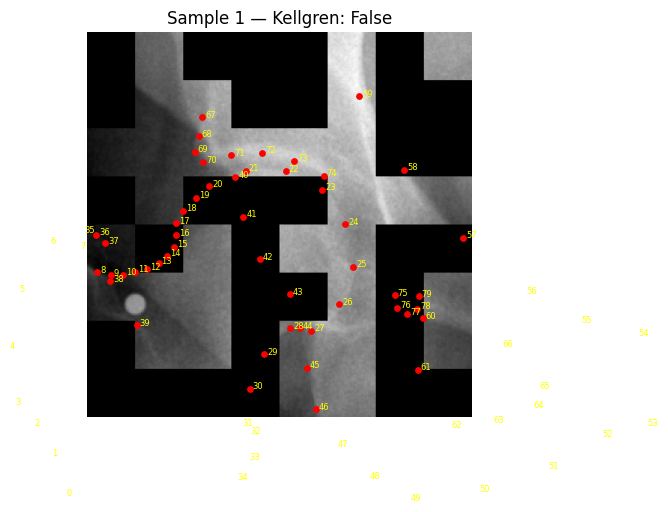

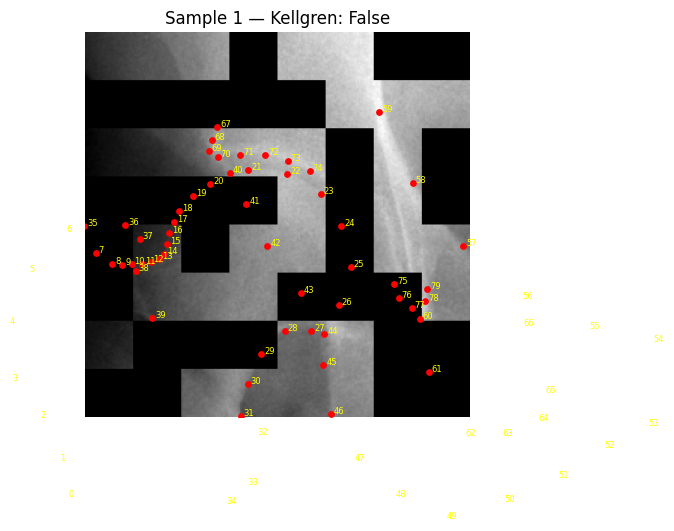

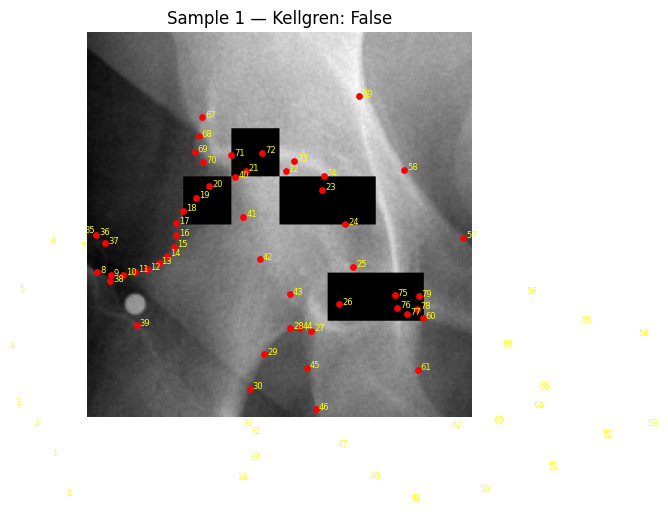

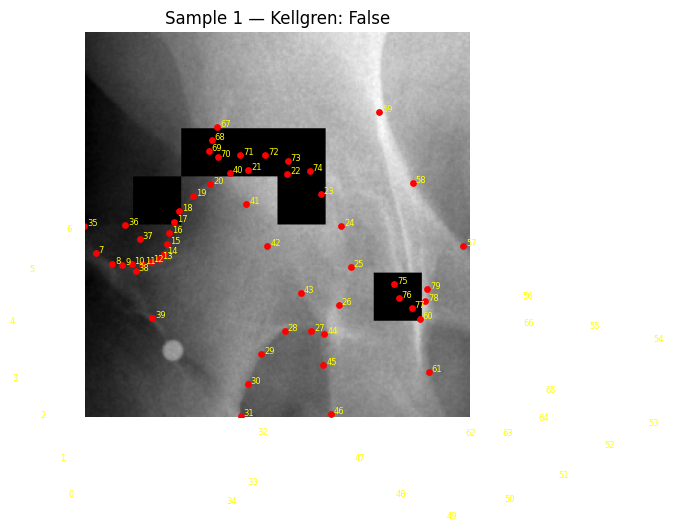

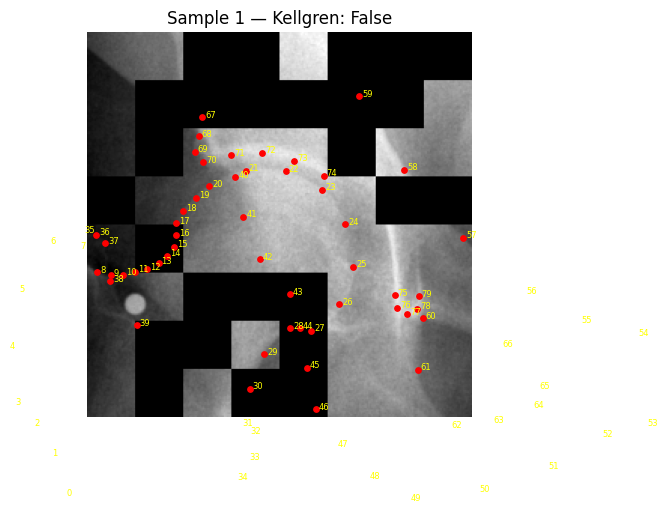

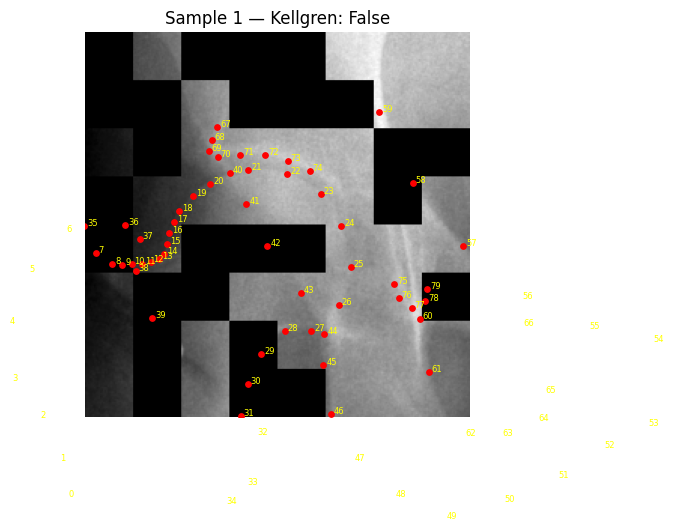

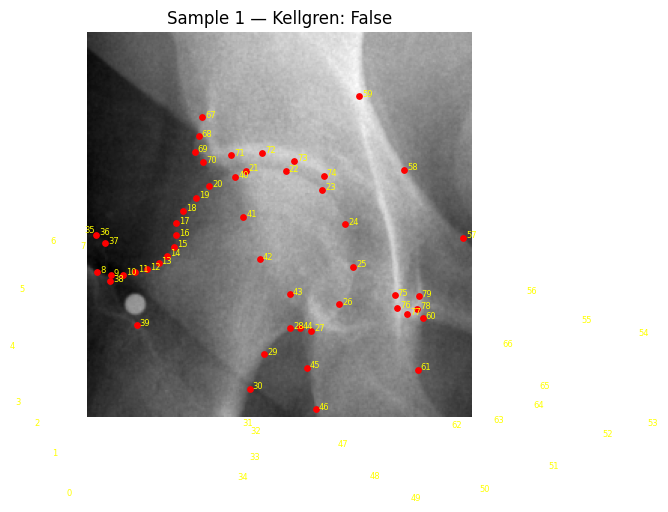

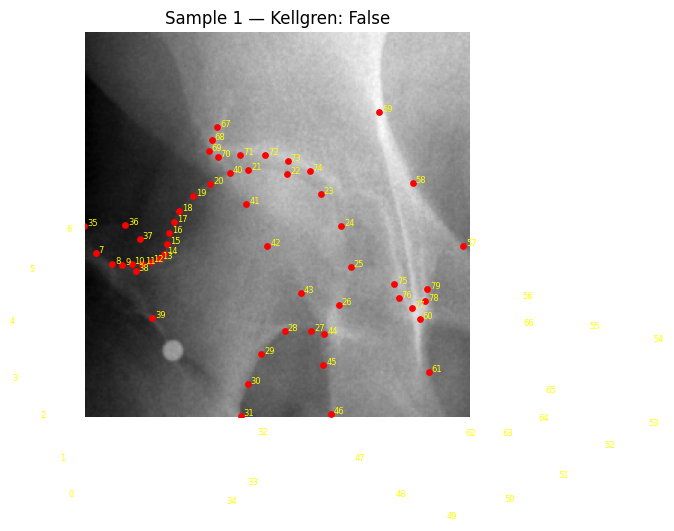

In [12]:
from matplotlib import transforms
import torch
from torchvision import transforms
from checkDataset import CheckDataset
from sample_dataset import sample_and_plot_from_loader

dataset_name = "check_test"

dataset = CheckDataset(
    processed_root="data/" + dataset_name,
    patients_path="data/" + dataset_name + "/patients",
    targets_json="data/"+ dataset_name + "/targets.json",
    split_txt="data/" + dataset_name + "/train_test_val_split.txt",
    desired_split="train",
    transform=transforms.Normalize(mean=[0.5], std=[0.5]), # normalize image intensity
    augment=False)

data_loader = torch.utils.data.DataLoader(
    dataset, 
    batch_size=8, 
    shuffle=False, #dont shuffle test sets 
    num_workers=2,
    pin_memory=True,
    persistent_workers=True)


print_masked = True
patch_size = 32
mask_rate = 0.5
num_samples = 1

_, height, width = data_loader.dataset[0]["image"].shape
num_patches = height // patch_size * width // patch_size
num_masked = int(num_patches * mask_rate)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': True,
    'mask_non_roi': True
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': True,
    'mask_non_roi': False
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': False,
    'mask_non_roi': True
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)

mask_params = {
    'height': height,
    'width': width,
    'num_patches': num_patches,
    'num_masked': num_masked,
    'patch_size': patch_size,
    'mask_rate': mask_rate,
    'mask_roi': False,
    'mask_non_roi': False
}
sample_and_plot_from_loader(data_loader, mask_params, num_samples, print_masked)
    


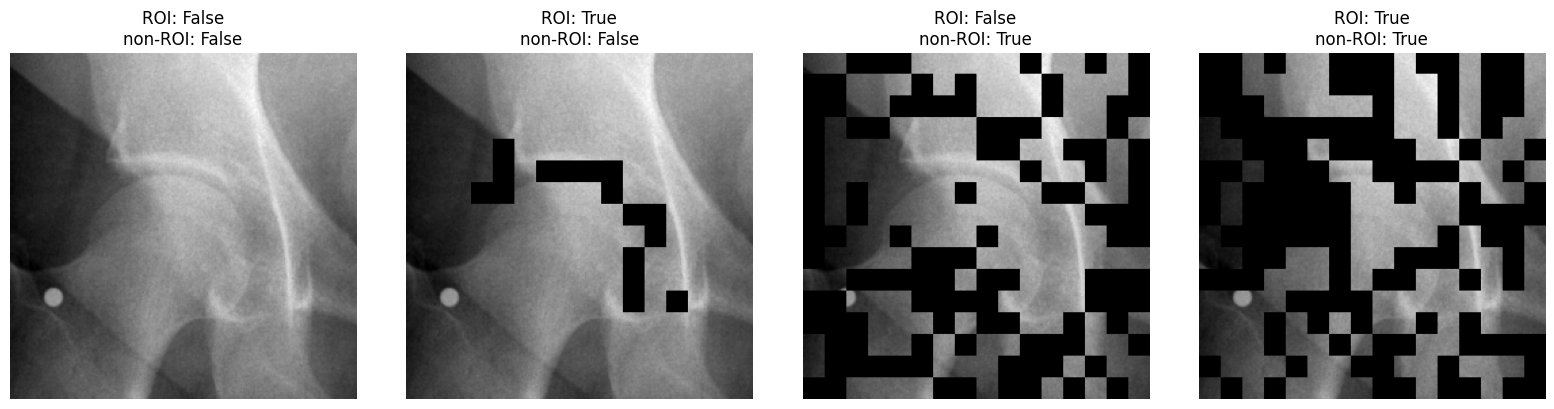

In [13]:
import torch
import matplotlib.pyplot as plt
from checkDataset import CheckDataset
from masking import mask_batch
import torchvision.transforms as T

# — your dataset & loader setup —
dataset_name = "check_test"
dataset = CheckDataset(
    processed_root=f"data/{dataset_name}",
    patients_path=f"data/{dataset_name}/patients",
    targets_json=f"data/{dataset_name}/targets.json",
    split_txt=f"data/{dataset_name}/train_test_val_split.txt",
    desired_split="train",
    transform=T.Normalize(mean=[0.5], std=[0.5]),
    augment=False
)
loader = torch.utils.data.DataLoader(
    dataset, batch_size=8, shuffle=False,
    num_workers=2, pin_memory=False, persistent_workers=False
)

# grab one batch, take first image
batch = next(iter(loader))
orig_img = batch["image"][0:1]       # [1, C, H, W]
roi_mask = batch["roi_mask"][0:1]    # [1, H, W]
points   = batch["points"][0:1]      # if you care, else can ignore

# base mask params
_, C, H, W = orig_img.shape
patch_size = 16
mask_rate  = 0.5
n_patches  = (H//patch_size)*(W//patch_size)
num_masked = int(n_patches * mask_rate)
base_params = dict(
    height=H, width=W,
    num_patches=n_patches,
    num_masked=num_masked,
    patch_size=patch_size,
    mask_rate=mask_rate
)

# the four (mask_ROI, mask_non_ROI) combos
combos = [
    (False, False),
    (True,  False),
    (False, True),
    (True,  True),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (mask_ROI, mask_non_ROI) in zip(axes, combos):
    params = base_params.copy()
    # call your new mask_batch signature:
    masked = mask_batch(
        {
            "image":    orig_img,
            "target":   batch["target"][0:1],
            "points":   batch["points"][0:1],
            "roi_mask": roi_mask
        },
        mask_ROI,
        mask_non_ROI,
        params
    )["image"]

    img = masked[0, 0].cpu().numpy()  # single‑channel → H×W
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"ROI: {mask_ROI}\nnon‑ROI: {mask_non_ROI}")
    ax.axis("off")

plt.tight_layout()
plt.show()



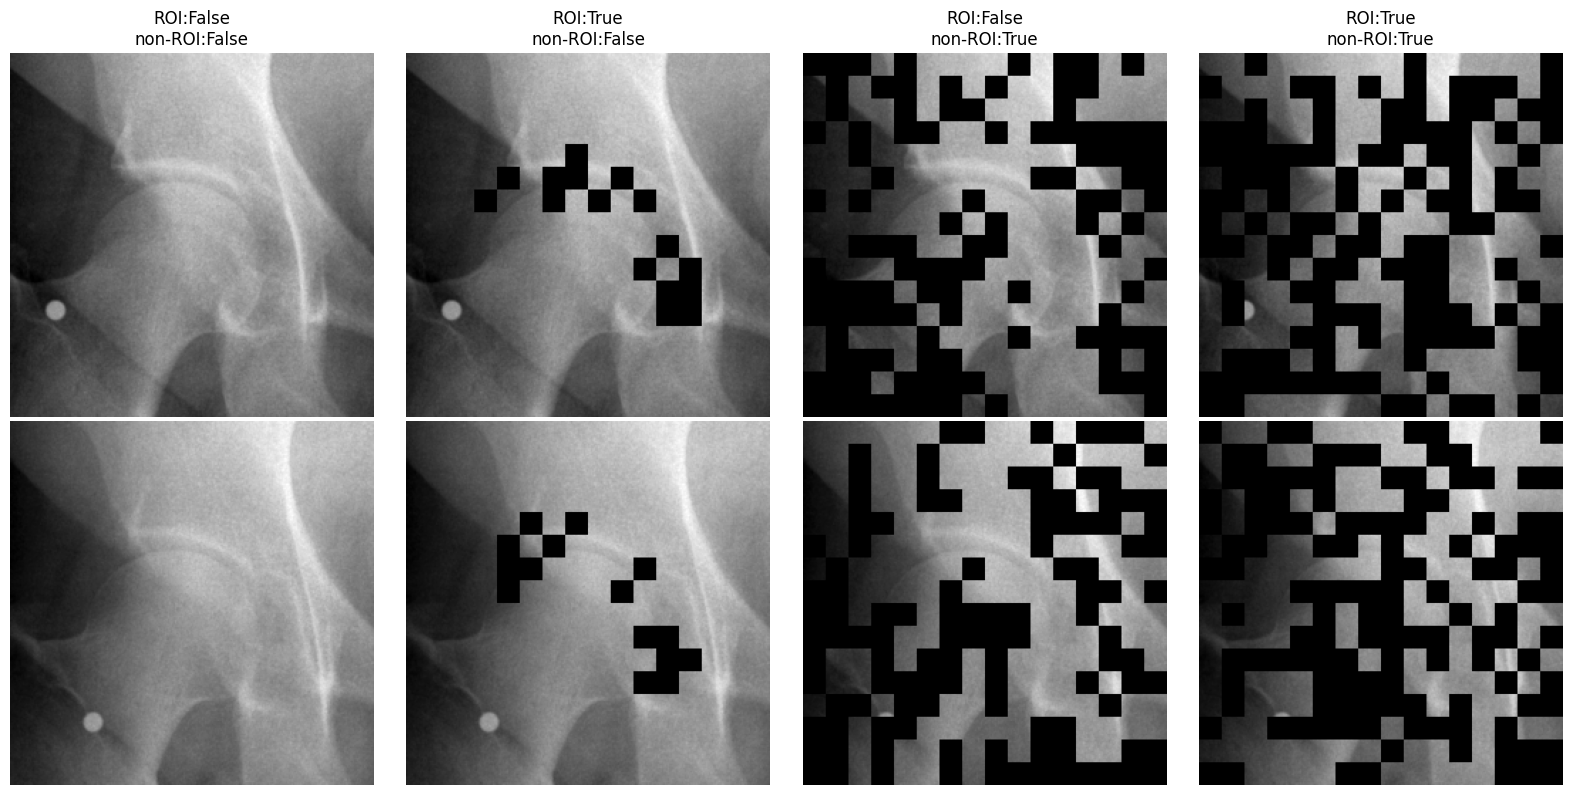

In [14]:
import torch
import matplotlib.pyplot as plt
from checkDataset import CheckDataset
from masking import mask_batch
import torchvision.transforms as T


# grab one batch
batch = next(iter(loader))
imgs    = batch["image"]      # [B, C, H, W]
roi     = batch["roi_mask"]   # [B, H, W]

B, C, H, W = imgs.shape

# base mask params
patch_size = 16
mask_rate  = 0.5
n_patches  = (H//patch_size)*(W//patch_size)
num_masked = int(n_patches * mask_rate)
base_params = dict(
    height=H, width=W,
    num_patches=n_patches,
    num_masked=num_masked,
    patch_size=patch_size,
    mask_rate=mask_rate
)

# the four (mask_ROI, mask_non_ROI) combos
combos = [
    (False, False),
    (True,  False),
    (False, True),
    (True,  True),
]
titles = ["ROI:False\nnon-ROI:False", "ROI:True\nnon-ROI:False",
          "ROI:False\nnon-ROI:True",  "ROI:True\nnon-ROI:True"]

fig, axes = plt.subplots(B, 4, figsize=(4*4, 4*B), squeeze=False)

for col, ((mask_ROI, mask_non_ROI), title) in enumerate(zip(combos, titles)):
    params = base_params.copy()
    for row in range(B):
        single = {
            "image":    imgs[row:row+1],
            "target":   batch["target"][row:row+1],
            "points":   batch["points"][row:row+1],
            "roi_mask": roi[row:row+1]
        }
        masked = mask_batch(single, mask_ROI, mask_non_ROI, params)["image"]
        img = masked[0, 0].cpu().numpy()

        ax = axes[row][col]
        ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
        if row == 0:
            ax.set_title(title)
        ax.axis("off")

plt.tight_layout()
plt.show()


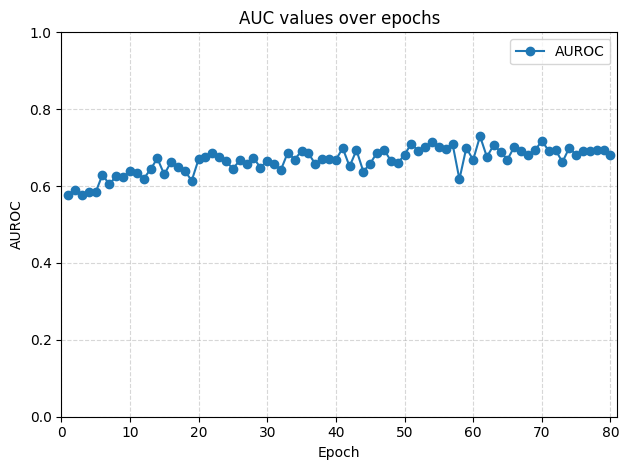

In [15]:
auc_list = [
    0.5769434168574232,
    0.590714928057554,
    0.5760492458306082,
    0.5843784489453892,
    0.5834721427403532,
    0.6297301647318508,
    0.6044430080935251,
    0.625981033355134,
    0.6230673131948985,
    0.6392652213456507,
    0.6352842441955526,
    0.6187216420045781,
    0.6436779553629823,
    0.6720678854643557,
    0.6302666673479398,
    0.6631325621321126,
    0.6500182666366907,
    0.6396797334859384,
    0.6139723164650098,
    0.6696140246893395,
    0.6761210349901897,
    0.6864052791857423,
    0.6756892781229562,
    0.6645466297416612,
    0.6452210390778288,
    0.6666964723675605,
    0.658086882766514,
    0.6737157149280575,
    0.6482126798561152,
    0.6656375183943755,
    0.6565374121157619,
    0.6425346938358404,
    0.6872381356278613,
    0.6689817180346631,
    0.6916591726618705,
    0.6852364699149771,
    0.6576091399607586,
    0.6700828257848267,
    0.6704289977109222,
    0.66845160235448,
    0.698813818263571,
    0.6510548663342053,
    0.6935126614617397,
    0.637862011527142,
    0.6585199170209287,
    0.6872777346304775,
    0.6949497220405493,
    0.6664461044800523,
    0.6588763080444735,
    0.6819382562132112,
    0.7102579300196206,
    0.691632347531066,
    0.7008742437867888,
    0.7148233118051014,
    0.702322800850229,
    0.6975709205362982,
    0.7096792736265534,
    0.6176869583878352,
    0.6992500459859385,
    0.6681629128515371,
    0.7297483036298233,
    0.6760111796926096,
    0.7068907374100719,
    0.6892551299869195,
    0.669104347204055,
    0.7025923295454546,
    0.690565729234794,
    0.6798854950130804,
    0.6926555346631785,
    0.7175428691137999,
    0.6922870084614127,
    0.6941820123446696,
    0.6624823720569,
    0.6994244093361676,
    0.6813238329790713,
    0.6906066056245912,
    0.6909578870994115,
    0.6933708714846306,
    0.6933900322923479,
    0.6821273095160235
]

# Plot
plt.plot(range(1, len(auc_list)+ 1), auc_list, marker='o', label='AUROC')
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.ylim(0.0, 1.0)
plt.xlim(0, 81)
plt.title("AUC values over epochs")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Save & close
plt.tight_layout()
plt.show()

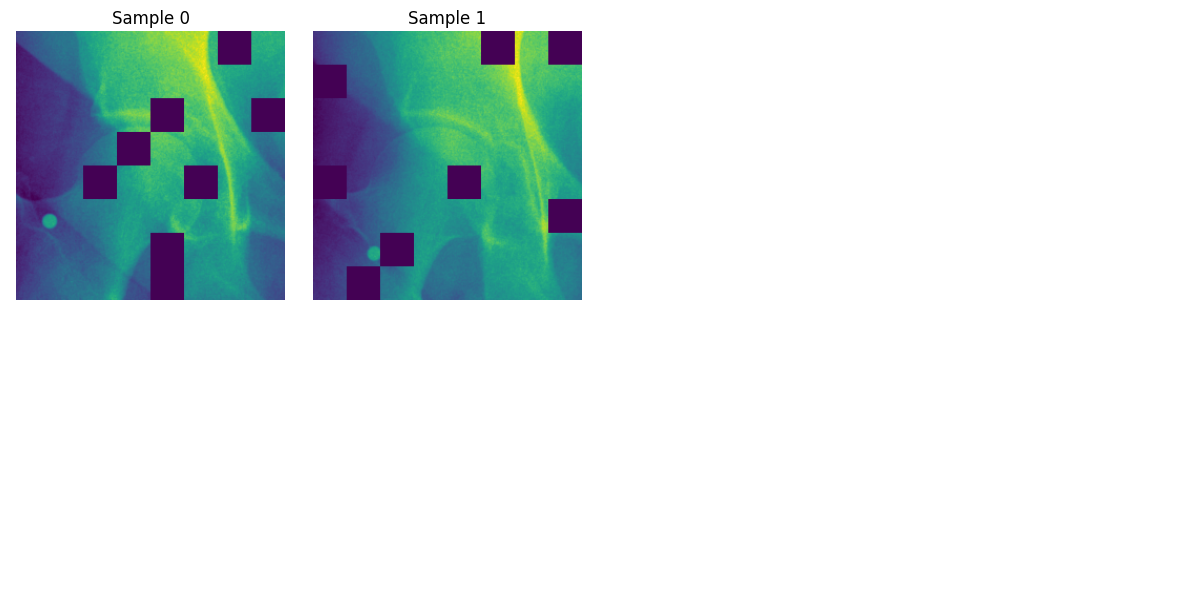

In [ ]:
import matplotlib.pyplot as plt
import torch

def plot_masked_grid(batch, mask_ROI=True, mask_non_ROI=True):
    # Define mask params
    mask_params = {
        "patch_size": 32,
        "mask_rate": 0.5,   # Only used for ROI and non-ROI
        "height": batch["image"].shape[2],
        "width": batch["image"].shape[3],
        "num_masked": 8     # Only used for full masking
    }

    # Apply masking
    masked_batch = mask_batch(batch, mask_ROI, mask_non_ROI, mask_params)
    images = masked_batch["image"]  # [B, C, H, W]

    # Convert to [0,1] for plotting
    images = (images + 1) / 2.0
    images = torch.clamp(images, 0, 1)

    B = images.shape[0]
    n_images = min(8, B)  # Show at most 8

    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    axs = axs.flatten()

    for i in range(n_images):
        img = images[i].permute(1, 2, 0).cpu().numpy()  # [H, W, C]
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(f"Sample {i}")

    # Hide any extra axes
    for j in range(n_images, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

batch = next(iter(loader))  # Or whatever loader you're using
plot_masked_grid(batch, mask_ROI=True, mask_non_ROI=True)
